# 03 — BG on a 2D double-well (KL by energy)

Goal: train a Boltzmann Generator **without any target samples**, using only the energy function `u(x,y) = a(x²-1)² + (y/σ_y)²/2`. Compare against an MCMC ground-truth.

This is the first notebook where we train via reverse-KL (`L_KL_z`). Pure KL_z is prone to mode collapse, so we use a **short ML pretrain** on MCMC samples (paper Sec. S4 strategy) followed by KL_z fine-tuning.


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import trange

from bg.flows import RealNVP, GaussianPrior, FlowModel
from bg.energies import DoubleWell2D
from bg.losses import kl_by_example, kl_by_energy
from bg.sampling import sample_with_weights, effective_sample_size, normalized_weights, free_energy_diff

torch.manual_seed(0); np.random.seed(0)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'device={device}')

device=mps


/Users/manumartinm/Documents/proyectos/boltzmann_generators/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Energy landscape

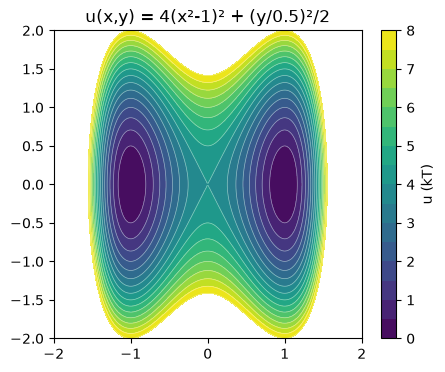

barrier height: 4.00 kT (at saddle (0,0))


In [2]:
dw = DoubleWell2D(a=4.0, sigma_y=0.5)
gx, gy, U = dw.grid(n=200, span=2.0)
fig, ax = plt.subplots(figsize=(5, 4))
levels = np.linspace(0, 8, 17)
cs = ax.contourf(gx.numpy(), gy.numpy(), U.numpy(), levels=levels, cmap='viridis')
ax.contour(gx.numpy(), gy.numpy(), U.numpy(), levels=levels, colors='white', linewidths=0.5, alpha=0.5)
ax.set_title('u(x,y) = 4(x²-1)² + (y/0.5)²/2'); ax.set_aspect('equal')
plt.colorbar(cs, ax=ax, label='u (kT)')
plt.show()
print(f'barrier height: {dw(torch.tensor([[0.0, 0.0]])).item():.2f} kT (at saddle (0,0))')

## 2. MCMC baseline (Metropolis with Gaussian proposals)

acceptance: 42.61%
MCMC samples: torch.Size([160000, 2])


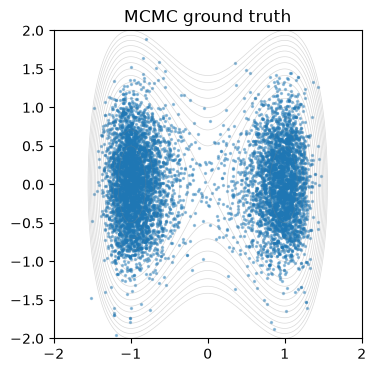

In [3]:
def mcmc(energy_fn, n_steps, x0=None, sigma=0.5, n_chains=1):
    if x0 is None:
        x0 = torch.zeros(n_chains, 2)
    x = x0.clone()
    samples = torch.empty(n_steps, n_chains, 2)
    u = energy_fn(x)
    accepted = 0
    for t in range(n_steps):
        x_new = x + sigma * torch.randn_like(x)
        u_new = energy_fn(x_new)
        accept = torch.rand(n_chains) < torch.exp(-(u_new - u))
        x = torch.where(accept[:, None], x_new, x)
        u = torch.where(accept, u_new, u)
        accepted += accept.sum().item()
        samples[t] = x
    print(f'acceptance: {accepted / (n_steps*n_chains):.2%}')
    return samples.reshape(-1, 2)

# multi-chain to ensure coverage of both wells
n_chains = 16
x0 = torch.zeros(n_chains, 2)
x0[:n_chains//2, 0] = -1.0   # half start at left well
x0[n_chains//2:, 0] = 1.0    # half start at right well
mcmc_samples = mcmc(dw, n_steps=10_000, x0=x0, sigma=0.4, n_chains=n_chains)
print(f'MCMC samples: {mcmc_samples.shape}')

fig, ax = plt.subplots(figsize=(5, 4))
ax.contour(gx.numpy(), gy.numpy(), U.numpy(), levels=levels, colors='gray', alpha=0.3, linewidths=0.5)
ax.scatter(mcmc_samples[::20, 0], mcmc_samples[::20, 1], s=2, alpha=0.4)
ax.set_title('MCMC ground truth'); ax.set_aspect('equal')
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
plt.show()

## 3. Build flow

In [4]:
flow = RealNVP(dim=2, num_layers=10, hidden_dim=64, num_hidden=2, mask='halves', scale_clip=3.0)
model = FlowModel(GaussianPrior(2), flow).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'#params: {n_params:,}')

#params: 46,120


## 4. ML pretrain on MCMC samples (forward KL)

ML pretrain:   0%|          | 0/1500 [00:00<?, ?it/s]

ML pretrain:   0%|          | 1/1500 [00:01<47:57,  1.92s/it]

ML pretrain:   0%|          | 4/1500 [00:02<09:50,  2.53it/s]

ML pretrain:   1%|          | 11/1500 [00:02<03:02,  8.17it/s]

ML pretrain:   1%|          | 14/1500 [00:02<02:29,  9.92it/s]

...

ML pretrain:  98%|█████████▊| 1467/1500 [00:27<00:00, 78.86it/s]

ML pretrain:  98%|█████████▊| 1475/1500 [00:27<00:00, 72.85it/s]

ML pretrain:  99%|█████████▉| 1483/1500 [00:27<00:00, 73.81it/s]

ML pretrain:  99%|█████████▉| 1492/1500 [00:28<00:00, 76.00it/s]

ML pretrain: 100%|██████████| 1500/1500 [00:28<00:00, 53.26it/s]

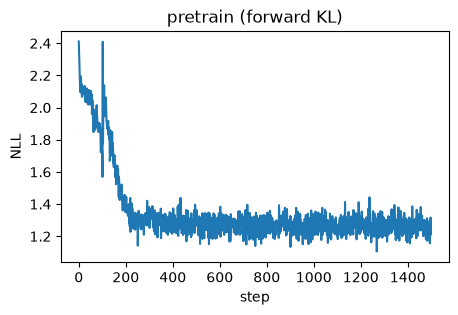

final pretrain NLL: 1.212


In [5]:
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
x_data = mcmc_samples.to(device)
hist = {'pretrain_nll': []}
for step in trange(1500, desc='ML pretrain'):
    idx = torch.randint(0, x_data.shape[0], (512,), device=device)
    loss = kl_by_example(model, x_data[idx])
    opt.zero_grad(); loss.backward(); opt.step()
    hist['pretrain_nll'].append(loss.item())

plt.figure(figsize=(5, 3))
plt.plot(hist['pretrain_nll']); plt.xlabel('step'); plt.ylabel('NLL'); plt.title('pretrain (forward KL)')
plt.show()
print(f'final pretrain NLL: {hist["pretrain_nll"][-1]:.3f}')

## 5. KL_z fine-tuning (reverse KL, no samples)

KL_z:   0%|          | 0/2000 [00:00<?, ?it/s]

KL_z:   0%|          | 1/2000 [00:00<16:11,  2.06it/s]

KL_z:   0%|          | 6/2000 [00:00<02:38, 12.60it/s]

KL_z:   1%|          | 11/2000 [00:00<01:32, 21.48it/s]

KL_z:   1%|          | 19/2000 [00:00<00:55, 35.71it/s]

...

KL_z:  99%|█████████▊| 1971/2000 [00:34<00:00, 50.34it/s]

KL_z:  99%|█████████▉| 1979/2000 [00:34<00:00, 56.16it/s]

KL_z:  99%|█████████▉| 1987/2000 [00:34<00:00, 61.67it/s]

KL_z: 100%|█████████▉| 1995/2000 [00:34<00:00, 65.62it/s]

KL_z: 100%|██████████| 2000/2000 [00:34<00:00, 57.73it/s]

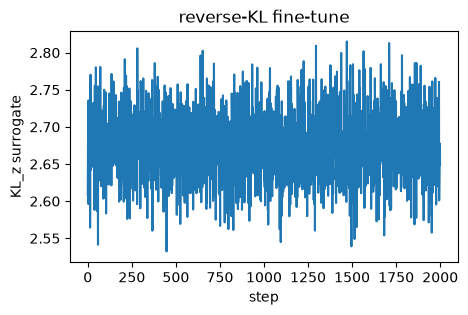

final KL_z loss: 2.649


In [6]:
opt = torch.optim.Adam(model.parameters(), lr=3e-4)
hist['kl_z'] = []
for step in trange(2000, desc='KL_z'):
    loss = kl_by_energy(model, dw, n_samples=512, device=device, energy_max=50.0)
    opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    opt.step()
    hist['kl_z'].append(loss.item())

plt.figure(figsize=(5, 3))
plt.plot(hist['kl_z']); plt.xlabel('step'); plt.ylabel('KL_z surrogate'); plt.title('reverse-KL fine-tune')
plt.show()
print(f'final KL_z loss: {hist["kl_z"][-1]:.3f}')

## 6. Sample + compare densities

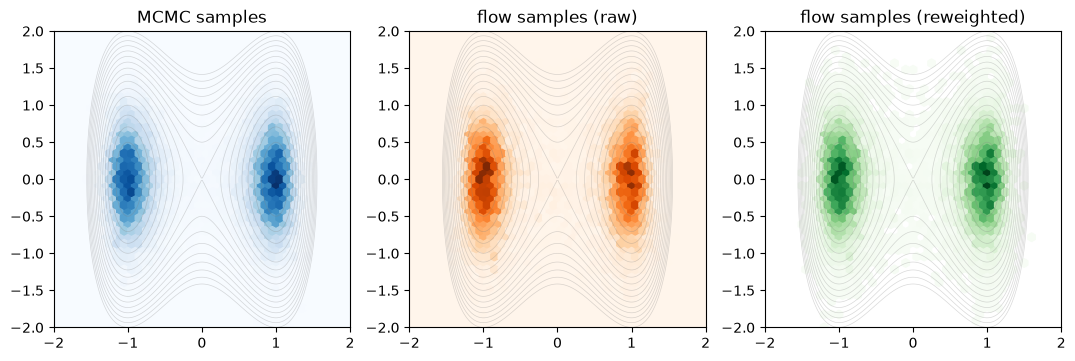

ESS = 19618.2 / 20000 = 98.1%


In [7]:
x_model, log_w, log_q = sample_with_weights(model, dw, n=20_000, device=device)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
# MCMC ref
axes[0].contour(gx.numpy(), gy.numpy(), U.numpy(), levels=levels, colors='gray', alpha=0.3, linewidths=0.5)
axes[0].hexbin(mcmc_samples[:, 0], mcmc_samples[:, 1], gridsize=40, cmap='Blues', extent=(-2, 2, -2, 2))
axes[0].set_title('MCMC samples'); axes[0].set_aspect('equal')
# Model unweighted
axes[1].contour(gx.numpy(), gy.numpy(), U.numpy(), levels=levels, colors='gray', alpha=0.3, linewidths=0.5)
axes[1].hexbin(x_model[:, 0], x_model[:, 1], gridsize=40, cmap='Oranges', extent=(-2, 2, -2, 2))
axes[1].set_title('flow samples (raw)'); axes[1].set_aspect('equal')
# Model reweighted
w = normalized_weights(log_w).numpy()
axes[2].contour(gx.numpy(), gy.numpy(), U.numpy(), levels=levels, colors='gray', alpha=0.3, linewidths=0.5)
axes[2].hexbin(x_model[:, 0], x_model[:, 1], C=w, reduce_C_function=np.sum, gridsize=40, cmap='Greens', extent=(-2, 2, -2, 2))
axes[2].set_title('flow samples (reweighted)'); axes[2].set_aspect('equal')
for ax in axes:
    ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
plt.show()

ess = effective_sample_size(log_w)
print(f'ESS = {ess:.1f} / 20000 = {ess/200:.1f}%')

## 7. Free-energy difference ΔF between wells (should be ~0 by symmetry)

In [8]:
region_left  = lambda x: x[:, 0] < 0
region_right = lambda x: x[:, 0] > 0

dF_bg = free_energy_diff(x_model, log_w, region_left, region_right)
# MCMC reference: just log(N_R/N_L)
nL = (mcmc_samples[:, 0] < 0).sum().item()
nR = (mcmc_samples[:, 0] > 0).sum().item()
dF_mcmc = -np.log(nR / nL)
print(f'ΔF(L→R) — BG  : {dF_bg:+.3f} kT')
print(f'ΔF(L→R) — MCMC: {dF_mcmc:+.3f} kT')
print(f'true value    : 0.000 kT (symmetry)')

ΔF(L→R) — BG  : +0.004 kT
ΔF(L→R) — MCMC: -0.042 kT
true value    : 0.000 kT (symmetry)


## 8. Verification

Expected:
- Reweighted flow samples reproduce the MCMC density visually.
- ESS > 10% indicates the flow is close to the target.
- ΔF estimate within ~0.1 kT of 0.

If the flow collapsed to one well: increase the pretrain dataset or its diversity (more chains), reduce `scale_clip`, or increase `num_layers`. The KL_z gradients can be brutal without good init.

Next: M6 (Müller-Brown — 3 modes, asymmetric).